In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Get Only Chennai City Restaurant

In [157]:
dataset1 = pd.read_csv("csao_session_dataset.csv")

# Checking only Chennai C
cleanData = dataset1[dataset1["user_city"] == "chennai"]


cleanData.rename(columns={
    'restaurant_name': 'Restaurant',
    'user_segment': 'Type',
    'restaurant_city': 'City',
    'restaurant_cuisine': 'Cuisine',
    'user_preferred_cuisine': 'User Cuisine',
    'meal_time': 'Meal',
    'delivery_zone': 'delivery_zone',
    'restaurant_type': 'Restaurant Type',
    'restaurant_online_order': 'Online Order',
    'restaurant_rating': 'Rating',
    'restaurant_delivery_time_avg': 'Avg Delivery Time',
    'restaurant_avg_orders_per_day': 'Avg Daily Orders',
    'final_order_value': 'Price',
    'user_preferred_addon_category': 'User Category'
    
    
    
    
}, inplace=True)

dataset = cleanData.iloc[:, [4,5,16,17,7,15,18,19,21,23,24,52]]

# Display all rows without truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

dataset.head()

/var/folders/xh/qbyhzlq91t96qsm5mpr0mrqr0000gn/T/ipykernel_1484/745331130.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Restaurant,Type,City,Cuisine,User Cuisine,User Category,Restaurant Type,Online Order,Rating,Avg Delivery Time,Avg Daily Orders,Price
2,SLV Corner - Branch 4,mid,chennai,south_indian,south_indian,dip,Casual Dining,Yes,4.150655,51.2,134,175.46
6,BOX8,mid,chennai,fast_food,south_indian,dip,Quick Bites,Yes,3.662274,43.9,74,724.85
22,Express Kitchen - Branch 3,budget,chennai,fast_food,continental,side,Delivery,Yes,4.034479,67.3,129,213.77
23,Oven Fresh,budget,chennai,desserts,desserts,bread,Bakery,Yes,3.851940,46.7,113,399.57
43,Spice Route - Branch 5,budget,chennai,north_indian,chinese,dip,Fine Dining,No,3.748512,51.0,122,343.22


In [125]:
dataset.shape

(12495, 12)

In [126]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12495 entries, 2 to 99998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Restaurant         12495 non-null  object 
 1   Type               12495 non-null  object 
 2   City               12495 non-null  object 
 3   Cuisine            12495 non-null  object 
 4   User Cuisine       12495 non-null  object 
 5   User Category      12495 non-null  object 
 6   Restaurant Type    12495 non-null  object 
 7   Online Order       12495 non-null  object 
 8   Rating             12495 non-null  float64
 9   Avg Delivery Time  12495 non-null  float64
 10  Avg Daily Orders   12495 non-null  int64  
 11  Price              12495 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 1.2+ MB


In [118]:
dataset.describe()

,Rating,Avg Delivery Time,Avg Daily Orders,Price
count,12495.000000,12495.000000,12495.000000,12495.000000
mean,3.939985,49.158207,96.912525,451.872928
std,0.356894,12.413716,31.911743,259.801984
min,2.720192,26.300000,29.000000,113.670000
25%,3.710666,38.900000,71.000000,254.120000
50%,3.919994,48.200000,102.000000,382.640000
75%,4.167679,57.600000,124.000000,578.410000
max,4.619786,75.000000,152.000000,1982.630000


Resturant Segment

In [127]:
segment = dataset['Type'].value_counts().reset_index()
segment.rename(columns={'Type':'Type', 'count':'COUNT OF RESTAURANTS'}, inplace=True)
segment

,Type,COUNT OF RESTAURANTS
0,mid,5225
1,budget,5130
2,premium,2140


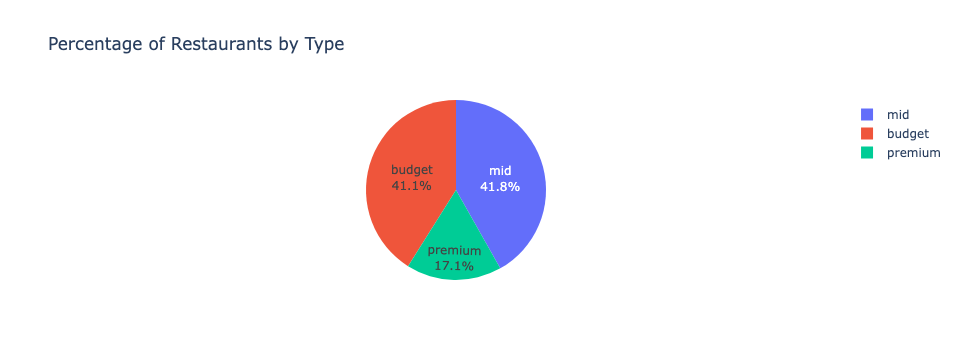

In [128]:
fig = px.pie(segment, names='Type',
             values='COUNT OF RESTAURANTS', color='Type', 
             title='Percentage of Restaurants by Type').update_traces(textposition='inside', 
                                                                             textinfo='percent+label')
fig.show()

In [129]:
resturant_type = dataset['Restaurant Type'].value_counts().reset_index()
resturant_type.rename(columns={'Restaurant Type':'Restaurant Type', 'count':'COUNT OF RESTAURANTS'}, inplace=True)
resturant_type

,Restaurant Type,COUNT OF RESTAURANTS
0,Quick Bites,3024
1,Casual Dining,2681
2,Delivery,2681
3,Fine Dining,1553
4,Food Court,1417
5,Cafe,686
6,Dessert Parlour,293
7,Bakery,160


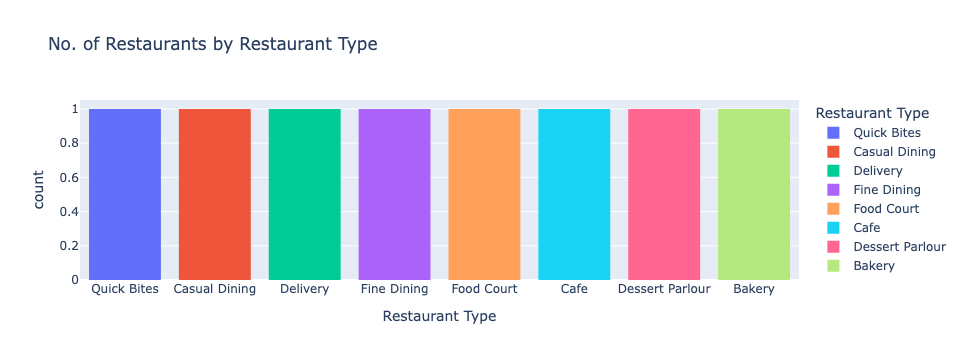

In [132]:
fig = px.histogram(resturant_type, x='Restaurant Type', color='Restaurant Type',
 title='No. of Restaurants by Restaurant Type',
 labels={'RESTAURANT TYPE':'Restaurant Type'}).update_xaxes(categoryorder="total descending")

fig.show()

# Get Resturant Online Delivery availabel and rating more then 4.2 

In [133]:
online_Order = dataset[(dataset['Online Order'] == "Yes") & (
    dataset["Rating"] >= 4.2)]
online_Order.head()

,Restaurant,Type,City,Cuisine,User Cuisine,User Category,Restaurant Type,Online Order,Rating,Avg Delivery Time,Avg Daily Orders,Price
91,The Belgian Waffle Co.,mid,chennai,desserts,chinese,side,Quick Bites,Yes,4.314779,37.2,90,225.84
125,Rebel Foods - Branch 3,mid,chennai,fast_food,arabian,dip,Food Court,Yes,4.491749,46.6,143,242.11
259,The Bigg Small Cafe - Branch 8,mid,chennai,north_indian,north_indian,dip,Casual Dining,Yes,4.282680,75.0,81,514.56
279,Barbeque Nation - Branch 2,budget,chennai,north_indian,chinese,side,Delivery,Yes,4.519377,69.7,70,376.37
294,China Bistro - Branch 3,budget,chennai,chinese,fast_food,dip,Food Court,Yes,4.401937,56.5,127,190.18


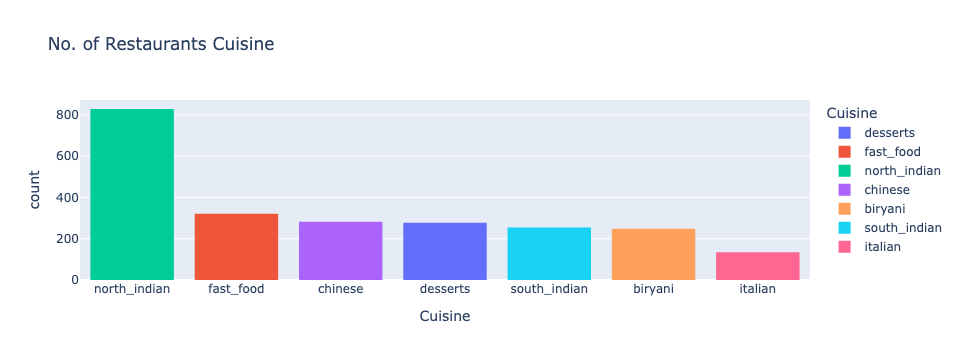

In [135]:
fig = px.histogram(online_Order, x='Cuisine', color='Cuisine',
 title='No. of Restaurants Cuisine',
 labels={'Cuisine':'Cuisine'}).update_xaxes(categoryorder="total descending")

fig.show()

In [136]:
cusines = dataset['User Cuisine'].value_counts().reset_index()
cusines.rename(columns={'User Cuisine':'User Cuisine', 'count':'COUNT OF RESTAURANTS'}, inplace=True)
cusines

,User Cuisine,COUNT OF RESTAURANTS
0,biryani,1587
1,fast_food,1505
2,desserts,1487
3,italian,1443
4,arabian,1439
5,north_indian,1356
6,south_indian,1314
7,chinese,1229
8,continental,1135


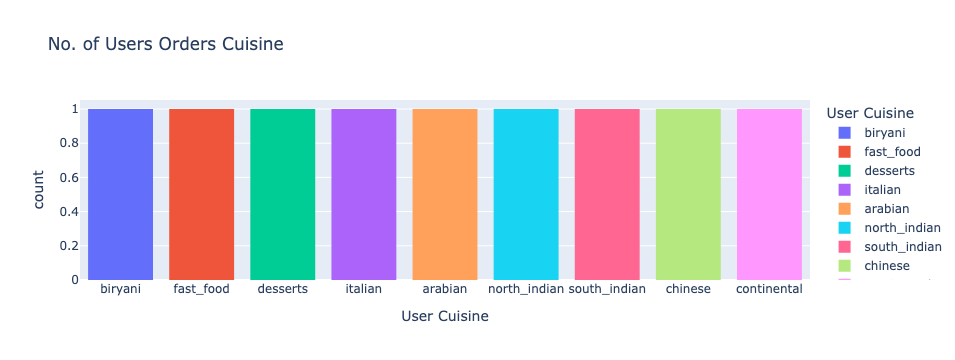

In [138]:
fig = px.histogram(cusines, x='User Cuisine', color='User Cuisine',
 title='No. of Users Orders Cuisine',
 labels={'User Cuisine':'User Cuisine'})

fig.show()

In [139]:
dataset['Rating'] = dataset['Rating'].astype('float64')


/var/folders/xh/qbyhzlq91t96qsm5mpr0mrqr0000gn/T/ipykernel_1484/2140349436.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [140]:
highest_rated_df = dataset[dataset['Rating'] >= 4.5]
highest_rated_df.head()

,Restaurant,Type,City,Cuisine,User Cuisine,User Category,Restaurant Type,Online Order,Rating,Avg Delivery Time,Avg Daily Orders,Price
209,Street Food Junction,mid,chennai,fast_food,chinese,dip,Quick Bites,No,4.521840,53.0,30,353.08
279,Barbeque Nation - Branch 2,budget,chennai,north_indian,chinese,side,Delivery,Yes,4.519377,69.7,70,376.37
296,Fast Fork - Branch 3,premium,chennai,fast_food,arabian,dessert,Quick Bites,Yes,4.550051,63.0,103,466.55
300,Biryani Blues - Branch 3,budget,chennai,biryani,north_indian,side,Quick Bites,Yes,4.619786,32.8,152,446.91
385,Barbeque Nation - Branch 2,budget,chennai,north_indian,biryani,bread,Delivery,Yes,4.519377,69.7,70,914.17


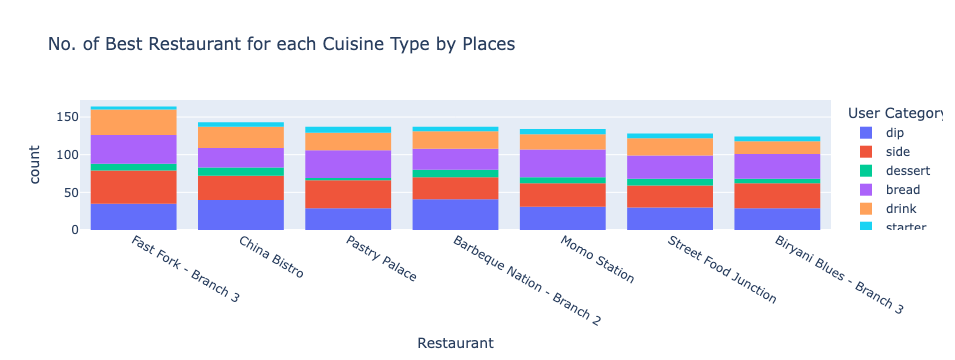

In [142]:
fig = px.histogram(highest_rated_df, x='Restaurant', color='User Category',
 title= 'No. of Best Restaurant for each Cuisine Type by Places').update_xaxes(categoryorder="total descending")
fig.show()

In [143]:
highest_rated_price_df = dataset.groupby(by=['Restaurant'])['Price'].mean().reset_index()
highest_rated_price_df.head()

,Restaurant,Cuisine,Price
0,Arabian Bites,arabian,354.200940
1,BOX8,fast_food,529.126190
2,Barbeque Nation - Branch 2,north_indian,751.602774
3,Bawarchi Restaurant,biryani,300.965612
4,Behrouz Biryani,biryani,512.233209


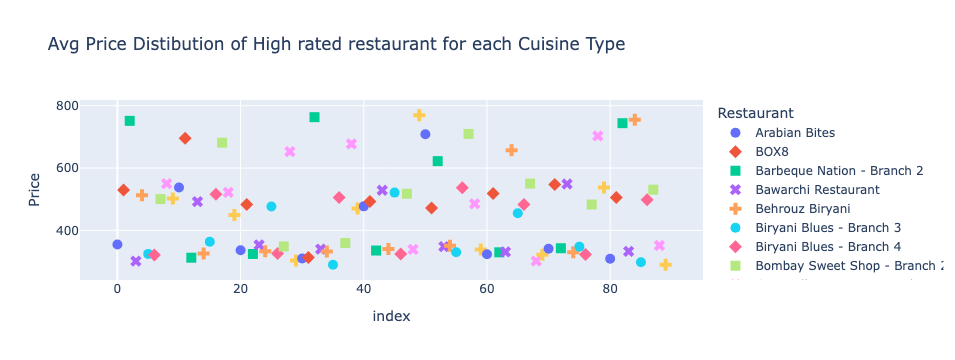

In [147]:
fig = px.scatter(highest_rated_price_df, y="Price", color="Restaurant", 
                 symbol="Restaurant",
                 title=' Avg Price Distibution of High rated restaurant for each Cuisine Type').update_traces(
    marker_size=10)
fig.show()

In [158]:
dataset.head()

,Restaurant,Type,City,Cuisine,User Cuisine,User Category,Restaurant Type,Online Order,Rating,Avg Delivery Time,Avg Daily Orders,Price
2,SLV Corner - Branch 4,mid,chennai,south_indian,south_indian,dip,Casual Dining,Yes,4.150655,51.2,134,175.46
6,BOX8,mid,chennai,fast_food,south_indian,dip,Quick Bites,Yes,3.662274,43.9,74,724.85
22,Express Kitchen - Branch 3,budget,chennai,fast_food,continental,side,Delivery,Yes,4.034479,67.3,129,213.77
23,Oven Fresh,budget,chennai,desserts,desserts,bread,Bakery,Yes,3.851940,46.7,113,399.57
43,Spice Route - Branch 5,budget,chennai,north_indian,chinese,dip,Fine Dining,No,3.748512,51.0,122,343.22


Which areas have a large number of Chinese Restaurant Market?

In [153]:
chinese_df = dataset[dataset['Cuisine'] == "chinese"]
chinese_df

,Restaurant,Type,City,Cuisine,User Cuisine,User Category,Restaurant Type,Online Order,Rating,Avg Delivery Time,Avg Daily Orders,Price
167,Canton Canteen,premium,chennai,chinese,chinese,starter,Food Court,Yes,4.069584,33.0,134,349.63
174,Fu Lin Kitchen,premium,chennai,chinese,fast_food,starter,Food Court,No,3.686115,41.5,57,334.46
251,Orient Kitchen - Branch 3,mid,chennai,chinese,italian,drink,Food Court,Yes,3.994411,45.5,129,190.64
294,China Bistro - Branch 3,budget,chennai,chinese,fast_food,dip,Food Court,Yes,4.401937,56.5,127,190.18
311,Orient Kitchen - Branch 3,budget,chennai,chinese,north_indian,side,Food Court,Yes,3.994411,45.5,129,371.46
378,Great Wall Restaurant - Branch 2,budget,chennai,chinese,italian,side,Casual Dining,Yes,3.752122,39.8,143,411.23
402,Hakka House,budget,chennai,chinese,chinese,dip,Food Court,Yes,3.790830,32.5,127,198.87
446,Hakka House,budget,chennai,chinese,arabian,bread,Food Court,Yes,3.790830,32.5,127,179.54
535,Great Wall Restaurant - Branch 2,mid,chennai,chinese,chinese,side,Casual Dining,Yes,3.752122,39.8,143,374.85
620,Great Wall Restaurant - Branch 2,mid,chennai,chinese,chinese,dip,Casual Dining,Yes,3.752122,39.8,143,270.33


In [154]:
online_orders = dataset[(dataset['Online Order'] == "Yes") & (dataset['Rating'] >= 4.2)]
online_orders

,Restaurant,Type,City,Cuisine,User Cuisine,User Category,Restaurant Type,Online Order,Rating,Avg Delivery Time,Avg Daily Orders,Price
91,The Belgian Waffle Co.,mid,chennai,desserts,chinese,side,Quick Bites,Yes,4.314779,37.2,90,225.84
125,Rebel Foods - Branch 3,mid,chennai,fast_food,arabian,dip,Food Court,Yes,4.491749,46.6,143,242.11
259,The Bigg Small Cafe - Branch 8,mid,chennai,north_indian,north_indian,dip,Casual Dining,Yes,4.282680,75.0,81,514.56
279,Barbeque Nation - Branch 2,budget,chennai,north_indian,chinese,side,Delivery,Yes,4.519377,69.7,70,376.37
294,China Bistro - Branch 3,budget,chennai,chinese,fast_food,dip,Food Court,Yes,4.401937,56.5,127,190.18
296,Fast Fork - Branch 3,premium,chennai,fast_food,arabian,dessert,Quick Bites,Yes,4.550051,63.0,103,466.55
300,Biryani Blues - Branch 3,budget,chennai,biryani,north_indian,side,Quick Bites,Yes,4.619786,32.8,152,446.91
345,Hotel Janatha Deluxe,budget,chennai,south_indian,biryani,side,Delivery,Yes,4.411437,66.0,117,145.42
373,Rebel Foods - Branch 3,mid,chennai,fast_food,italian,dip,Food Court,Yes,4.491749,46.6,143,168.66
375,The Belgian Waffle Co.,premium,chennai,desserts,desserts,drink,Quick Bites,Yes,4.314779,37.2,90,461.67


In [170]:
# Fixed the syntax error by removing the extra period after groupby
chinese_rest_df = online_orders.groupby(by='Restaurant').agg({'Restaurant' : 'count', 'Price' : 'mean'}).rename(
    columns= {'Restaurant' : 'COUNT OF RESTAURANTS', 'Price': 'Price'}).reset_index()

# chinese_rest_df = chinese_rest_df.sort_values('COUNT OF RESTAURANTS', ascending=False).head(25)
# chinese_rest_df.head()
chinese_rest_df

,Restaurant,COUNT OF RESTAURANTS,Price
0,Barbeque Nation - Branch 2,137,751.602774
1,Biryani Blues - Branch 3,124,324.235565
2,Biryani Blues - Branch 4,125,320.865920
3,China Bistro - Branch 3,148,362.976014
4,Dhaba by Claridges,120,521.940250
5,Fast Fork - Branch 3,164,476.385488
6,Gulshan Dhaba - Branch 5,148,763.370338
7,Hotel Janatha Deluxe,140,289.369143
8,Momo Station,134,517.448955
9,Nandhini Restaurant,115,769.549217


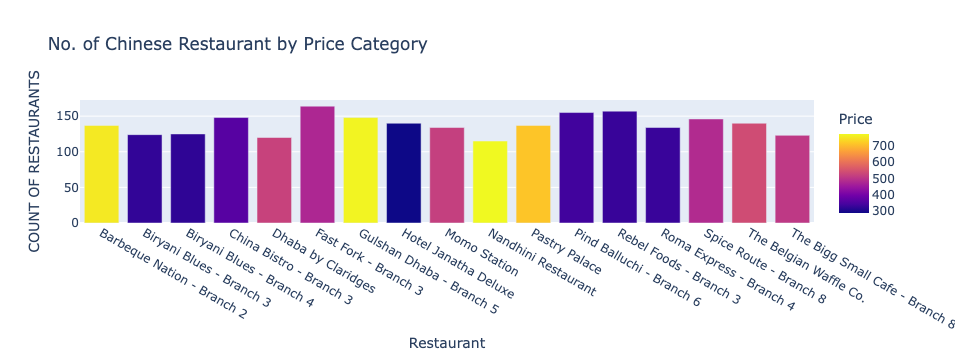

In [171]:
fig = px.bar(chinese_rest_df, x='Restaurant', y='COUNT OF RESTAURANTS', 
             color='Price', title='No. of Chinese Restaurant by Price Category')
fig.show()